# 06 — Star-Forming Galaxies: IR-to-Gamma Chain

Star-forming galaxies produce gamma rays from cosmic-ray interactions with
the ISM. Their gamma-ray luminosity correlates tightly with total infrared
luminosity via Ackermann et al. (2012). The underlying IR LF uses
Gruppioni et al. (2013) three-component modified Schechter form
(spirals, starbursts, SF-AGN composites).

**References:** `docs/equations.md` §5 (Eqs. 5.12–5.15); Gruppioni+ (2013);
Ackermann+ (2012).

In [ ]:
import sys
from pathlib import Path

def _find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / 'pyproject.toml').exists() and (candidate / 'hi_gamma_xcorr').is_dir():
            return candidate
    raise RuntimeError(f'Could not locate repo root from {start}')

REPO_ROOT = _find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import matplotlib.pyplot as plt
from hi_gamma_xcorr import config as cfg, cosmology as cosmo
from hi_gamma_xcorr import plotting as sty
cosmo.init()
print("Pipeline initialized.")

Pipeline initialized.


In [ ]:
from hi_gamma_xcorr import astro_sources as astro

\
## 1. Gruppioni IR LF Components (Eqs. 5.12–5.13)

Three populations with modified Schechter form, each with independent
luminosity and density evolution.

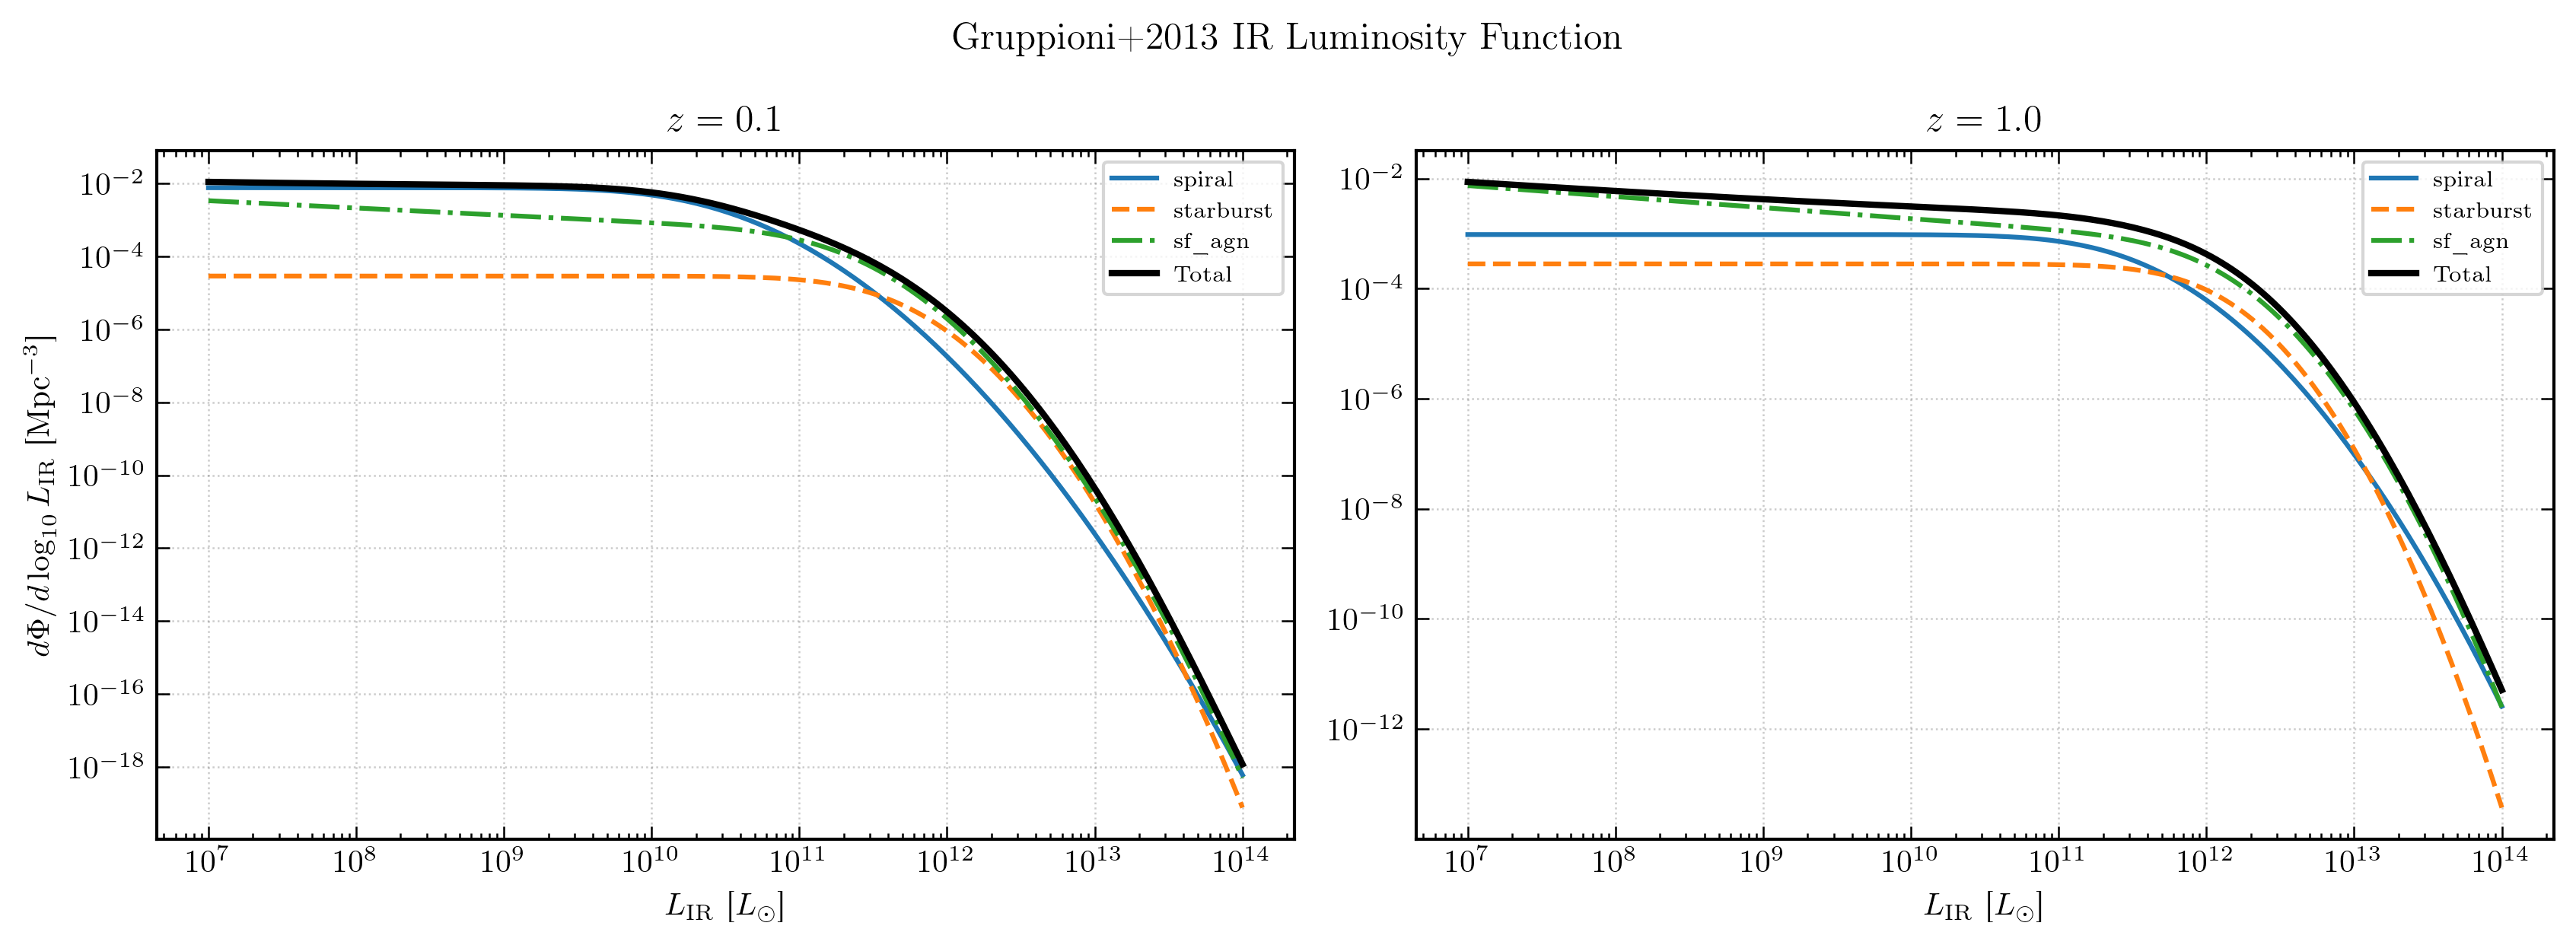

In [ ]:
L_IR = np.logspace(7, 14, 200)  # L_sun
fig, axes = plt.subplots(1, 2, figsize=(sty.TEXTWIDTH_IN * 1.5, sty.TEXTWIDTH_IN * 0.55))
for z, ax in zip([0.1, 1.0], axes):
    total = np.zeros_like(L_IR)
    for comp, ls in [('spiral', '-'), ('starburst', '--'), ('sf_agn', '-.')]:
        phi = np.array([astro._gruppioni_component(L, z, comp) for L in L_IR])
        ax.loglog(L_IR, phi, ls=ls, lw=sty.LW_STANDARD, label=comp)
        total += phi
    ax.loglog(L_IR, total, 'k', lw=sty.LW_MEDIUM, label='Total')
    ax.set_xlabel(r'$L_\mathrm{IR}$ [$L_\odot$]')
    ax.set_title(f'$z = {z}$'); ax.legend(fontsize=7)
axes[0].set_ylabel(r'$d\Phi/d\log_{10}L_\mathrm{IR}$ [Mpc$^{-3}$]')
fig.suptitle('Gruppioni+2013 IR Luminosity Function'); fig.tight_layout()

\
## 2. Ackermann $L_\gamma$--$L_\mathrm{IR}$ Scaling (Eq. 5.14)

$$\log_{10}\frac{L_\gamma}{\mathrm{erg\,s}^{-1}} = 1.09\,\log_{10}\frac{L_\mathrm{IR}}{10^{10}L_\odot} + 39.19$$

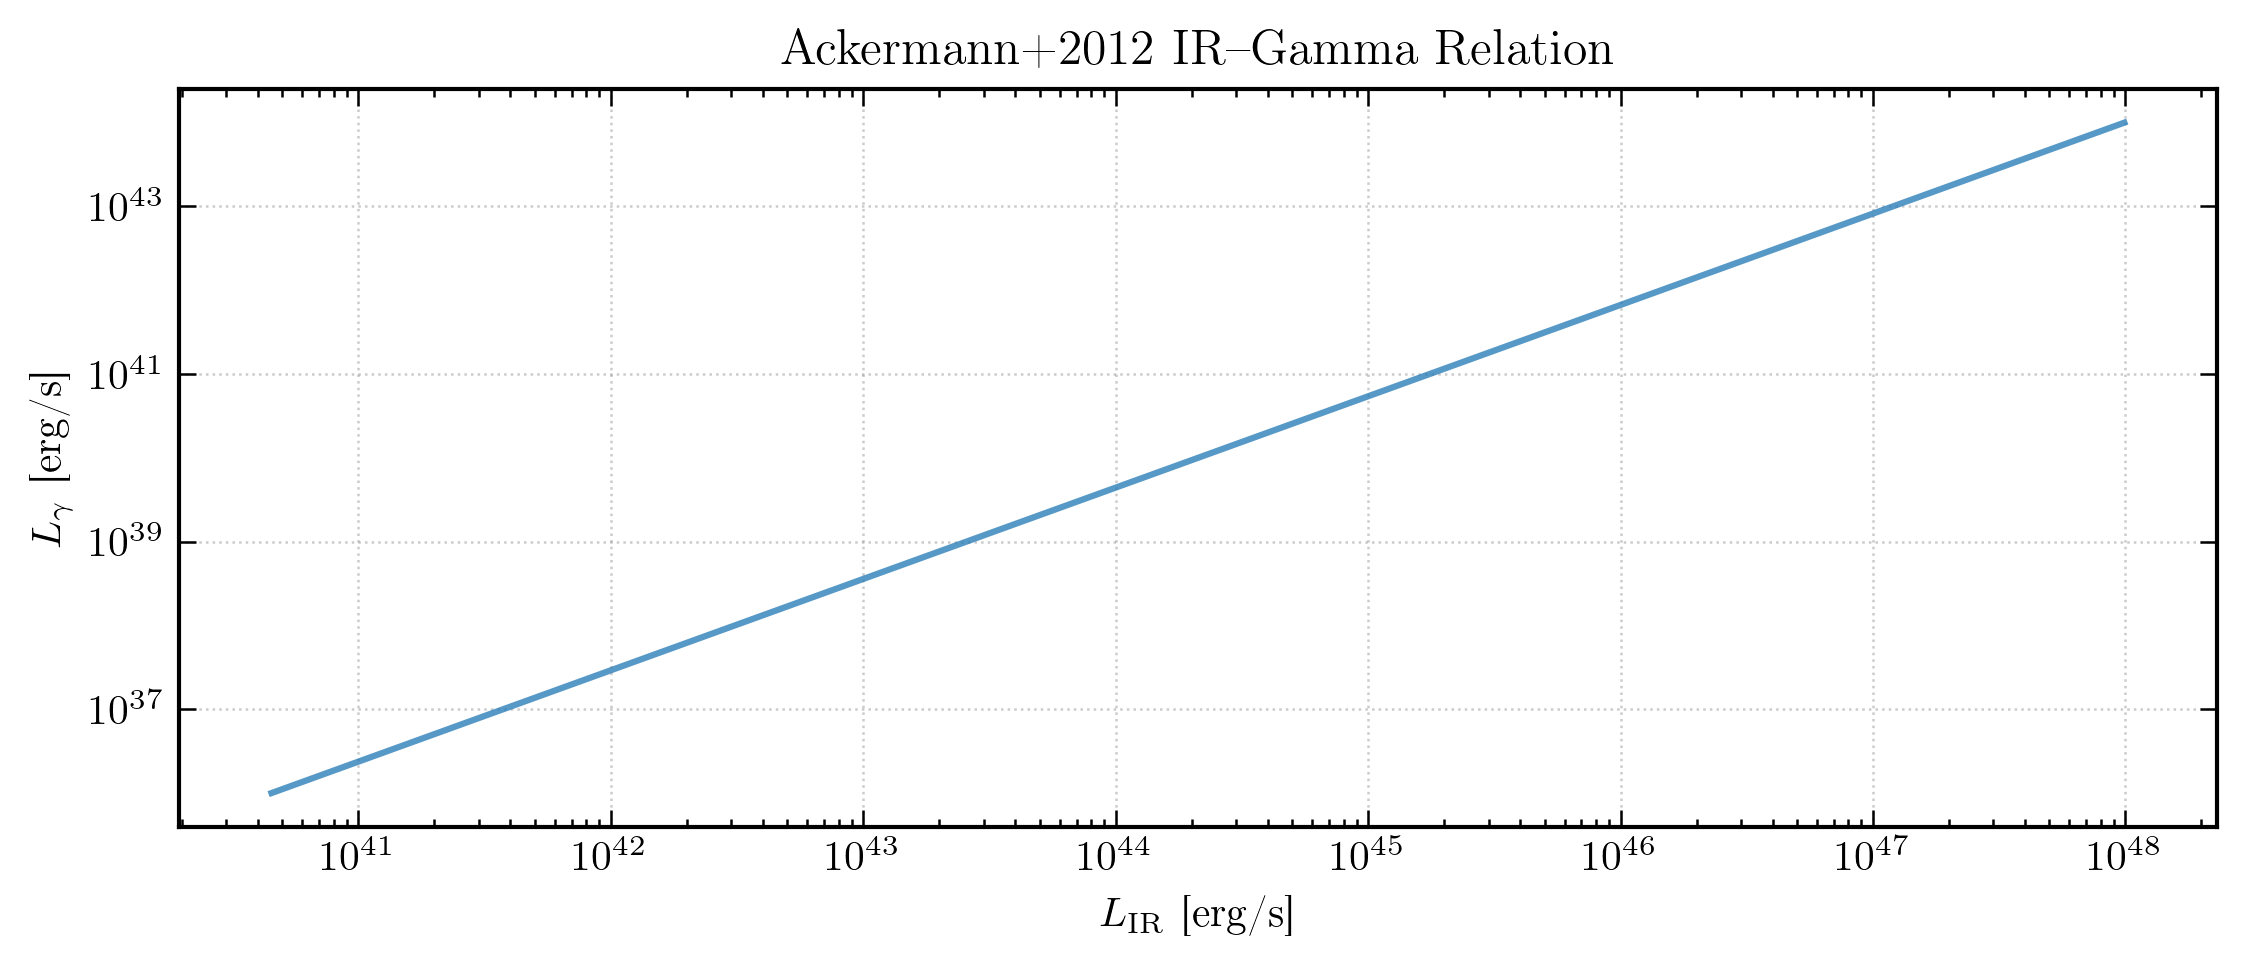

In [ ]:
Lgamma = np.logspace(36, 44, 100)
LIR, jac = zip(*[astro._L_IR_from_Lgamma(L) for L in Lgamma])
LIR = np.array(LIR)

fig, ax = sty.textwidth_figure(7)
ax.loglog(LIR * cfg.L_SUN, Lgamma, **sty.FIT_STYLE)
ax.set_xlabel(r'$L_\mathrm{IR}$ [erg/s]'); ax.set_ylabel(r'$L_\gamma$ [erg/s]')
ax.set_title('Ackermann+2012 IR--Gamma Relation'); fig.tight_layout()

## 3. SFG GLF and Comparison

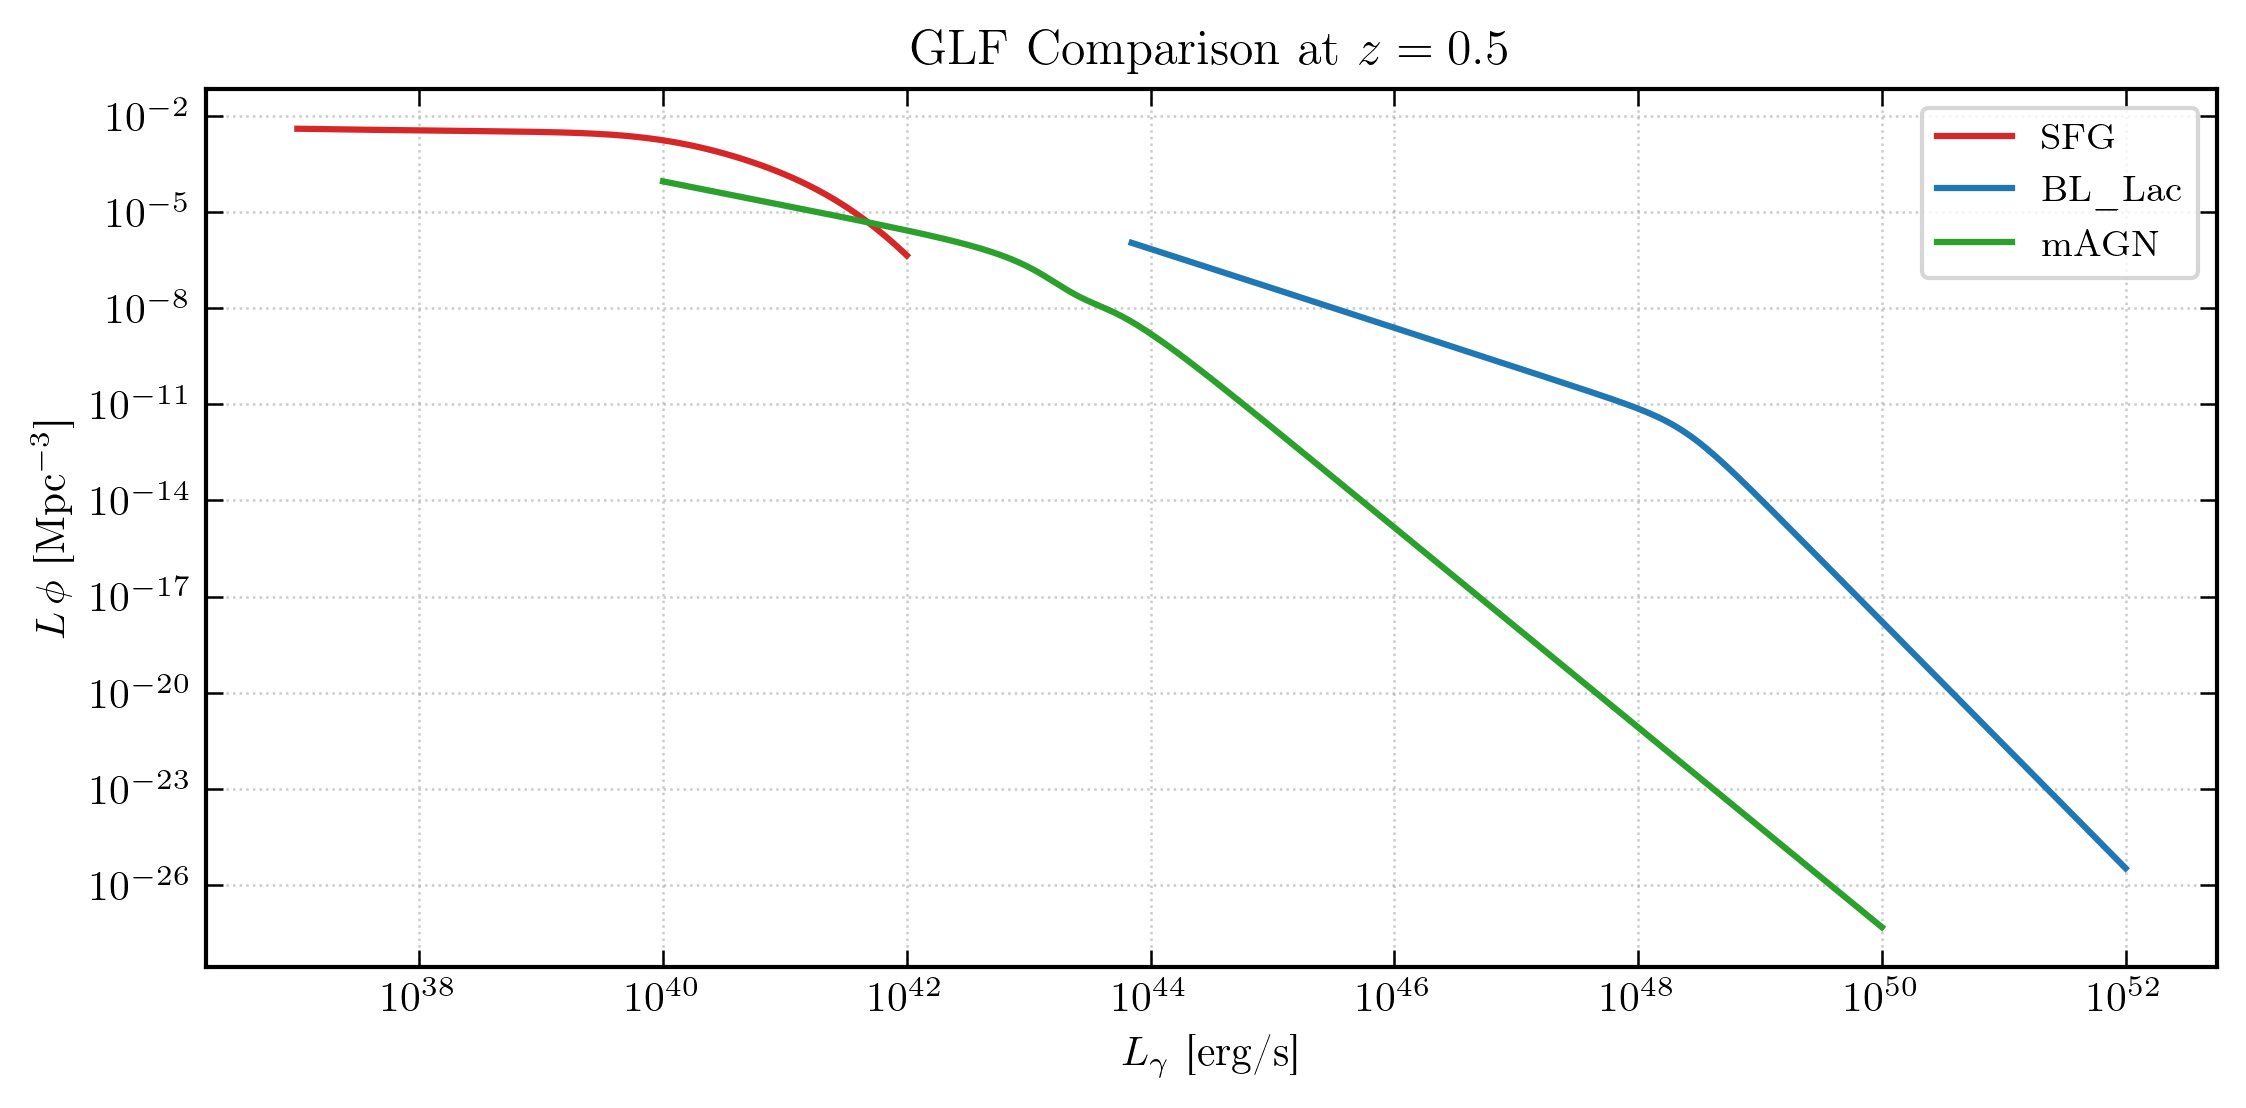

In [ ]:
fig, ax = sty.textwidth_figure(8)
for src, color in [('SFG', 'C3'), ('BL_Lac', 'C0'), ('mAGN', 'C2')]:
    L_range = np.logspace(np.log10(cfg.ASTRO_SOURCES[src]['L_min']),
                          np.log10(cfg.ASTRO_SOURCES[src]['L_max']), 200)
    phi = np.array([astro.glf(L, 0.5, src) for L in L_range])
    ax.loglog(L_range, L_range * phi, color=color, lw=sty.LW_STANDARD, label=src)
ax.set_xlabel(r'$L_\gamma$ [erg/s]'); ax.set_ylabel(r'$L\,\phi$ [Mpc$^{-3}$]')
ax.set_title('GLF Comparison at $z=0.5$'); ax.legend(); fig.tight_layout()

## 4. All-Source UGRB Spectrum

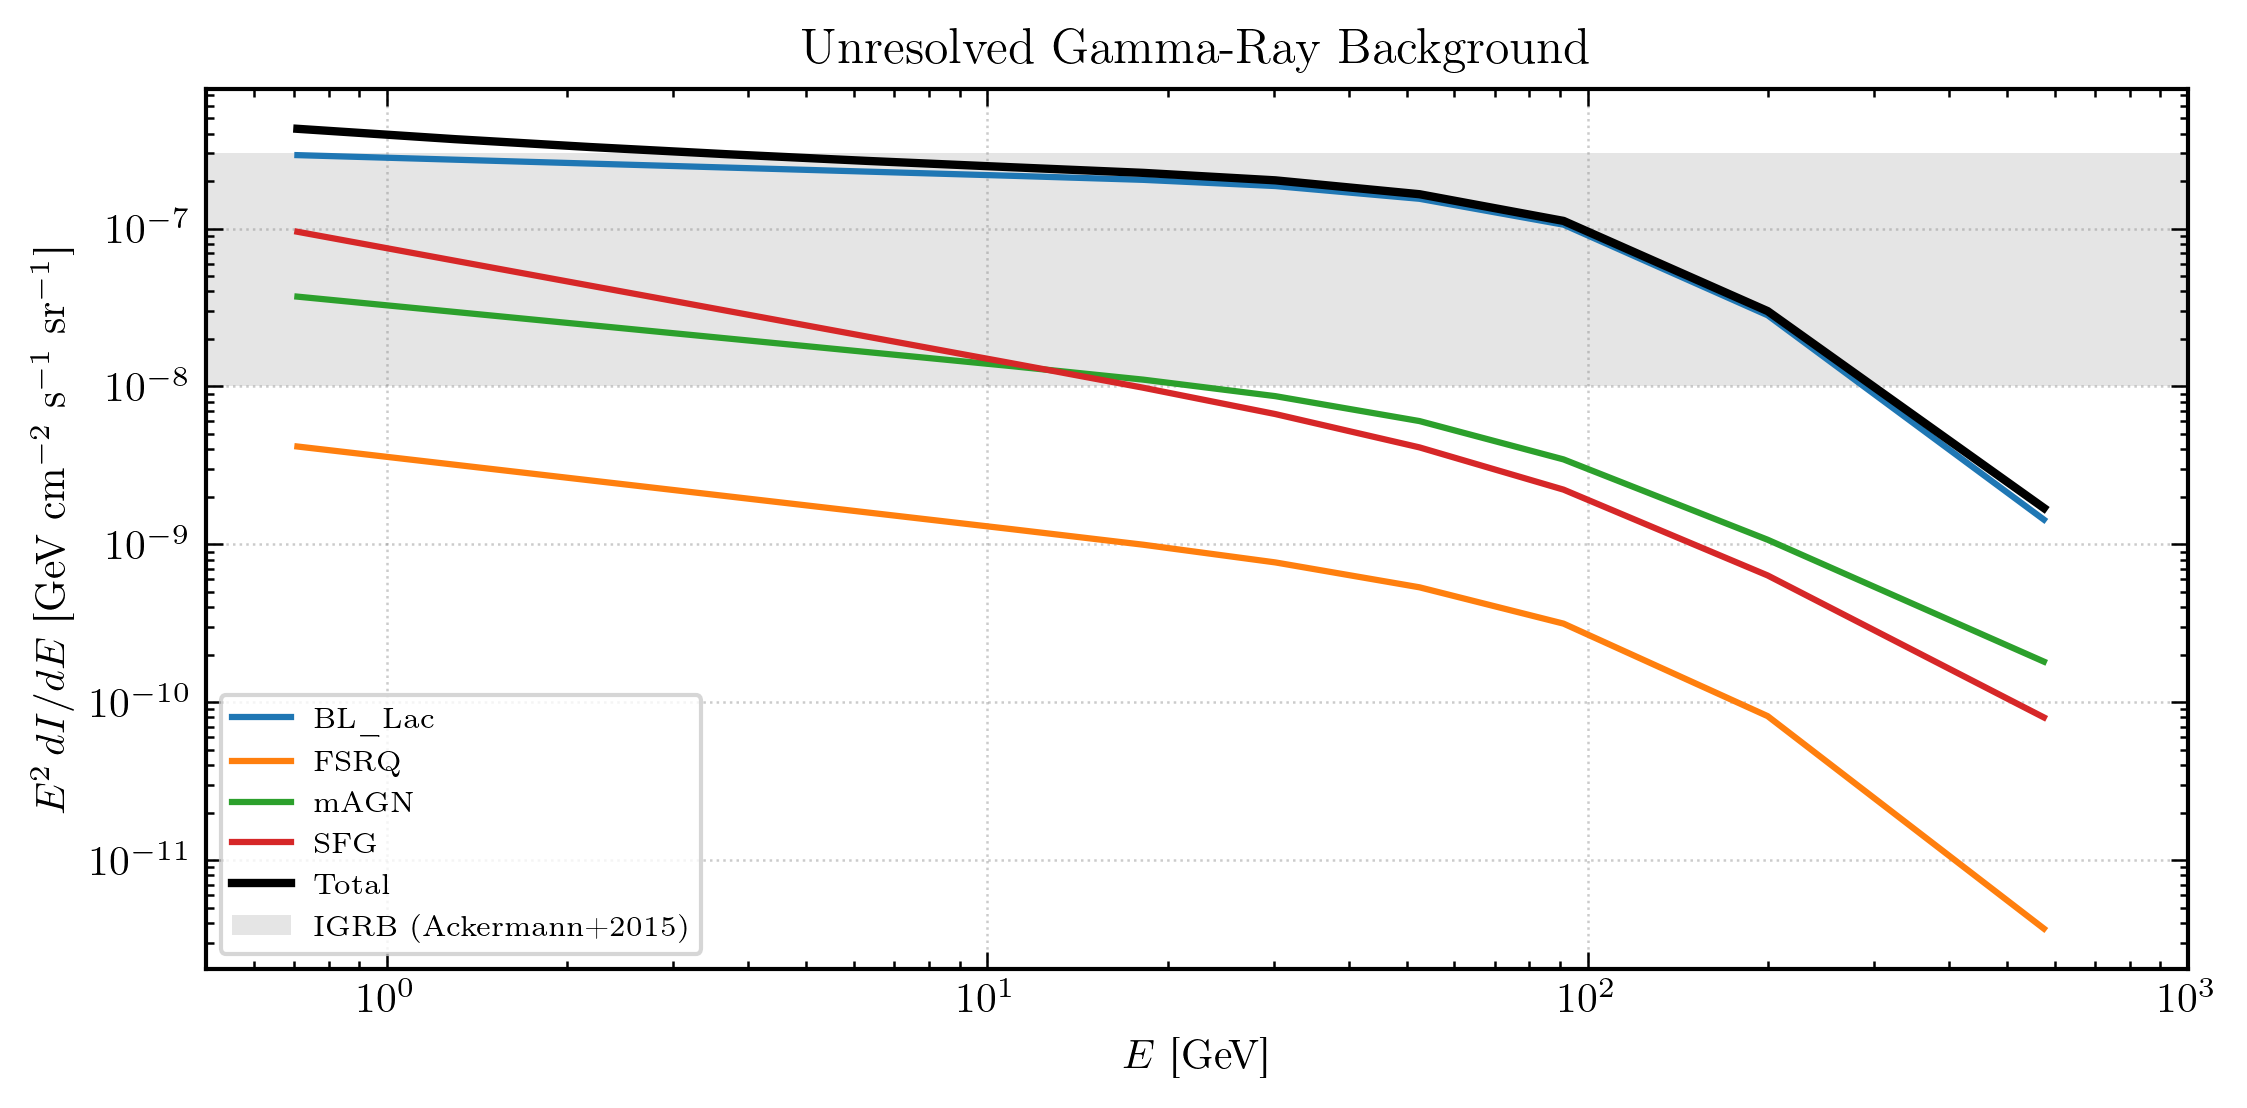

In [ ]:
E_arr = cfg.FERMI_E_B
sources = ['BL_Lac', 'FSRQ', 'mAGN', 'SFG']
colors = {'BL_Lac': 'C0', 'FSRQ': 'C1', 'mAGN': 'C2', 'SFG': 'C3'}

fig, ax = sty.textwidth_figure(8)
total = np.zeros_like(E_arr)
for src in sources:
    I = np.array([astro.mean_intensity(E, src) for E in E_arr])
    ax.loglog(E_arr, E_arr**2 * I, color=colors[src], lw=sty.LW_STANDARD, label=src)
    total += I
ax.loglog(E_arr, E_arr**2 * total, 'k-', lw=sty.LW_MEDIUM, label='Total')
ax.axhspan(1e-8, 3e-7, **sty.FILL_STYLE, color=sty.NEUTRAL_COLOR, label='IGRB (Ackermann+2015)')
ax.set_xlabel('$E$ [GeV]'); ax.set_ylabel(r'$E^2\,dI/dE$ [GeV cm$^{-2}$ s$^{-1}$ sr$^{-1}$]')
ax.set_title('Unresolved Gamma-Ray Background'); ax.legend(fontsize=7)
ax.set_xlim(0.5, 1000); fig.tight_layout()